
#### Real-World Applications:

1. Customer Service: Route tickets by urgency/sentiment with appropriate responses
2. Content Moderation: Binary classification (approved/flagged) with confidence
3. Email Response: Generate tone-appropriate replies based on sentiment strength
4. Review Analysis: Classify and respond to product reviews with matching intensity
5. Social Media Management: Brand-appropriate responses scaled to sentiment

In [9]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
load_dotenv()

True

In [6]:
llm = ChatOpenAI(model="gpt-4o")
llm.invoke('Hi')

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_02e9bb85b6', 'id': 'chatcmpl-DT78fjp1W5HPNyd5r6fRjBdry9q5m', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d77cb-9515-7541-a610-62ff59fbe37c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
class SentimentAnalysis(TypedDict):
    sentiment: str
    confidence: float
    reason: str


class SentimentState(TypedDict):
    original_tweet: str
    sentiment: str
    confidence: float
    response_tweet: str


In [8]:
llm.with_structured_output(SentimentAnalysis).invoke('Analyze below tweet: This is a very bad product')

{'sentiment': 'Negative',
 'confidence': 0.95,
 'reason': "The use of words like 'very bad' indicates a strong negative sentiment."}

In [15]:
# nodes
def analyze_sentiment(state:SentimentState):
    tweet = state['original_tweet']

    structured_llm = llm.with_structured_output(SentimentAnalysis)
    messages = [
        SystemMessage("Analyze sentiment and provide the structured output. Use 0 to 1.0 scale for confidence. lower is negative and higher is positive"),
        HumanMessage(tweet)
    ]
    analysis = structured_llm.invoke(messages)
    return analysis


In [16]:
state = {'original_tweet': "Just launched my new product!"}
state = analyze_sentiment(state)
state

{'sentiment': 'positive',
 'confidence': 0.9,
 'reason': 'The statement expresses excitement and accomplishment associated with launching a new product.'}

In [17]:
def generate_postive_response(state: SentimentState):
    
    print(f"current state in positive respone node: {state}")

    messages = [
        SystemMessage(f"""Generate a warm response to this positive tweet under 280 chars.
                      Confidence: {state['confidence']}. High confidence means be enthusiastic otherwise be friendly."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}


In [18]:
def generate_negative_response(state: SentimentState):
    print(f"current state in negative respone node: {state}")

    messages = [
        SystemMessage(f"""Generate and empathetic response to this negative tweet under 280 chars.
                      If Confidence {state['confidence']} is very low then be empathetic otherwise 
                      be understanding."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}


In [19]:
def route_by_sentiment(state: SentimentState):
    if state['sentiment'] == 'positive':
        return "positive_response"
    else:
        return "negative_response"

In [20]:

def create_router_graph():
    builder = StateGraph(SentimentState)
    
    # add nodes
    builder.add_node("analyze", analyze_sentiment)
    builder.add_node("positive_response", generate_postive_response)
    builder.add_node("negative_response", generate_negative_response)

    # edges
    builder.add_edge(START, "analyze")


    builder.add_conditional_edges("analyze", route_by_sentiment, ["positive_response", "negative_response"])

    builder.add_edge("positive_response", END)
    builder.add_edge("negative_response", END)

    graph = builder.compile()

    return graph

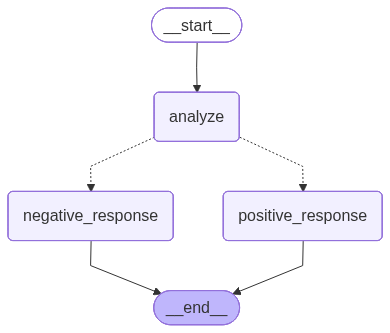

In [21]:
graph = create_router_graph()

graph

In [22]:
tweet = "Just launched my new product! the response from everyone has been amazing so far."

result = graph.invoke({'original_tweet': tweet})
result

current state in positive respone node: {'original_tweet': 'Just launched my new product! the response from everyone has been amazing so far.', 'sentiment': 'positive', 'confidence': 0.95}


{'original_tweet': 'Just launched my new product! the response from everyone has been amazing so far.',
 'sentiment': 'positive',
 'confidence': 0.95,
 'response_tweet': "That's fantastic news! 🎉 Huge congrats on your product launch! It's incredible to hear that the response has been so positive. Wishing you continued success and support from everyone! Keep shining! 🌟"}

In [ ]:
# Do the same practice for customer support use case -
# generate 50 fake reviews and keep it in JSON and build your entire langgraph using one feedback and then
# pass entire JSON to the graph
# reviews - Happy, angry etc --> email --> send (MCP)
